# COMPARISON

In [4]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")



In [14]:
TICKERS = ["AMZN", "AAPL", "MSFT", "GOOG", "TSLA"]
MODELS_DIR = "../models"
PROCESSED_DIR = "../data/processed"

FEATURE_COLS = [
    # Original
    "Returns", "SMA_5", "SMA_20", "Volatility_5", "Volatility_20",
    "Volume_Change", "RSI_14", "Price_Range",
    # New
    "MACD", "MACD_Signal", "MACD_Hist",
    "BB_Width", "BB_Position",
    "Momentum_10", "Momentum_20",
    "ATR_Ratio",
    "Return_Lag1", "Return_Lag2", "Return_Lag3", "Return_Lag5",
    "Volume_Ratio",
    "DayOfWeek",
    "Dist_SMA_5", "Dist_SMA_20",
]

In [10]:
def available_binary_vs_multi():
    """
    Compare results between binary and multi-class models.
    Run this AFTER running both notebooks.
    """
    
    results = []

    
    for ticker in TICKERS:
        row = {"Ticker": ticker}
        
        # Binary
        binary_path = f"{MODELS_DIR}/model_{ticker}_binary.joblib"
        if os.path.exists(binary_path):
            row["Binary Model"] = "✓"
        else:
            row["Binary Model"] = "✗"
        
        # Multi-class
        multi_path = f"{MODELS_DIR}/model_{ticker}_multi.joblib"
        if os.path.exists(multi_path):
            row["Multi Model"] = "✓"
        else:
            row["Multi Model"] = "✗"
        
        results.append(row)
    
    df = pd.DataFrame(results)
    print("Model Availability:")
    print(df.to_string(index=False))
    
    return df

available_binary_vs_multi()

Model Availability:
Ticker Binary Model Multi Model
  AMZN            ✓           ✓
  AAPL            ✓           ✓
  MSFT            ✓           ✓
  GOOG            ✓           ✓
  TSLA            ✓           ✓


,Ticker,Binary Model,Multi Model
0,AMZN,✓,✓
1,AAPL,✓,✓
2,MSFT,✓,✓
3,GOOG,✓,✓
4,TSLA,✓,✓


In [15]:
def compare_binary_vs_multi():
    """
    Compare Binary and Multi-Class model performance.
    
    For fair comparison:
    1. Evaluate each on their respective targets
    2. Convert multi-class predictions to binary and compare direction accuracy
    3. Visualize side-by-side
    """
    
    results = []
    
    print("="*70)
    print("BINARY vs MULTI-CLASS MODEL COMPARISON")
    print("="*70)
    
    for ticker in TICKERS:
        print(f"\n{'─'*70}")
        print(f"  {ticker}")
        print(f"{'─'*70}")
        
        # ── Load data ──
        path = f"{PROCESSED_DIR}/{ticker.lower()}_processed.csv"
        df = pd.read_csv(path, parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)
        df = df.dropna(subset=FEATURE_COLS + ["Target_Binary", "Target_Multi"])
        
        # Split (same as training)
        split_idx = int(len(df) * 0.7)
        X_test = df[FEATURE_COLS].iloc[split_idx:]
        y_test_binary = df["Target_Binary"].iloc[split_idx:].astype(int)
        y_test_multi = df["Target_Multi"].iloc[split_idx:].astype(int)
        
        row = {"Ticker": ticker}
        
        # ── Evaluate Binary Model ──
        try:
            binary_model = joblib.load(f"{MODELS_DIR}/model_{ticker}_binary.joblib")
            
            y_pred_binary = binary_model.predict(X_test)
            y_proba_binary = binary_model.predict_proba(X_test)[:, 1]
            
            binary_acc = accuracy_score(y_test_binary, y_pred_binary)
            binary_f1 = f1_score(y_test_binary, y_pred_binary)
            binary_auc = roc_auc_score(y_test_binary, y_proba_binary)
            
            row["Binary_Acc"] = round(binary_acc, 4)
            row["Binary_F1"] = round(binary_f1, 4)
            row["Binary_AUC"] = round(binary_auc, 4)
            
            print(f"  Binary Model:")
            print(f"    Accuracy: {binary_acc:.4f}")
            print(f"    F1 Score: {binary_f1:.4f}")
            print(f"    AUC-ROC:  {binary_auc:.4f}")
            
        except Exception as e:
            print(f"  Binary Model: ERROR - {e}")
            row["Binary_Acc"] = np.nan
            row["Binary_F1"] = np.nan
            row["Binary_AUC"] = np.nan
        
        # ── Evaluate Multi-Class Model ──
        try:
            multi_model = joblib.load(f"{MODELS_DIR}/model_{ticker}_multi.joblib")
            
            y_pred_multi = multi_model.predict(X_test)
            y_proba_multi = multi_model.predict_proba(X_test)
            
            multi_acc = accuracy_score(y_test_multi, y_pred_multi)
            multi_f1_macro = f1_score(y_test_multi, y_pred_multi, average="macro")
            multi_f1_weighted = f1_score(y_test_multi, y_pred_multi, average="weighted")
            
            row["Multi_Acc"] = round(multi_acc, 4)
            row["Multi_F1_Macro"] = round(multi_f1_macro, 4)
            row["Multi_F1_Weighted"] = round(multi_f1_weighted, 4)
            
            print(f"\n  Multi-Class Model:")
            print(f"    Accuracy:    {multi_acc:.4f}")
            print(f"    F1 Macro:    {multi_f1_macro:.4f}")
            print(f"    F1 Weighted: {multi_f1_weighted:.4f}")
            
            # ── Convert Multi-Class to Binary for fair comparison ──
            # Classes 0,1 (Big Fall, Small Fall) → 0 (Fall)
            # Classes 2,3 (Small Rise, Big Rise) → 1 (Rise)
            y_pred_multi_as_binary = (y_pred_multi >= 2).astype(int)
            
            multi_as_binary_acc = accuracy_score(y_test_binary, y_pred_multi_as_binary)
            multi_as_binary_f1 = f1_score(y_test_binary, y_pred_multi_as_binary)
            
            row["Multi_as_Binary_Acc"] = round(multi_as_binary_acc, 4)
            row["Multi_as_Binary_F1"] = round(multi_as_binary_f1, 4)
            
            print(f"\n  Multi-Class → Binary (direction only):")
            print(f"    Accuracy: {multi_as_binary_acc:.4f}")
            print(f"    F1 Score: {multi_as_binary_f1:.4f}")
            
            # ── Which is better for direction? ──
            if binary_acc > multi_as_binary_acc:
                winner = "Binary"
                diff = binary_acc - multi_as_binary_acc
            else:
                winner = "Multi→Binary"
                diff = multi_as_binary_acc - binary_acc
            
            row["Direction_Winner"] = winner
            print(f"\n  → Direction Winner: {winner} (+{diff:.4f})")
            
        except Exception as e:
            print(f"  Multi-Class Model: ERROR - {e}")
            row["Multi_Acc"] = np.nan
            row["Multi_F1_Macro"] = np.nan
            row["Multi_F1_Weighted"] = np.nan
            row["Multi_as_Binary_Acc"] = np.nan
            row["Multi_as_Binary_F1"] = np.nan
            row["Direction_Winner"] = "N/A"
        
        results.append(row)
    
    # ── Summary DataFrame ──
    comparison_df = pd.DataFrame(results)
    
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    
    return comparison_df


# Run comparison
comparison_df = compare_binary_vs_multi()
comparison_df

BINARY vs MULTI-CLASS MODEL COMPARISON

──────────────────────────────────────────────────────────────────────
  AMZN
──────────────────────────────────────────────────────────────────────
  Binary Model:
    Accuracy: 0.4918
    F1 Score: 0.3357
    AUC-ROC:  0.5314

  Multi-Class Model:
    Accuracy:    0.2350
    F1 Macro:    0.2315
    F1 Weighted: 0.2299

  Multi-Class → Binary (direction only):
    Accuracy: 0.4836
    F1 Score: 0.4392

  → Direction Winner: Binary (+0.0082)

──────────────────────────────────────────────────────────────────────
  AAPL
──────────────────────────────────────────────────────────────────────
  Binary Model:
    Accuracy: 0.4836
    F1 Score: 0.4358
    AUC-ROC:  0.4768

  Multi-Class Model:
    Accuracy:    0.2705
    F1 Macro:    0.2338
    F1 Weighted: 0.2475

  Multi-Class → Binary (direction only):
    Accuracy: 0.4645
    F1 Score: 0.5025

  → Direction Winner: Binary (+0.0191)

──────────────────────────────────────────────────────────────────

,Ticker,Binary_Acc,Binary_F1,Binary_AUC,Multi_Acc,Multi_F1_Macro,Multi_F1_Weighted,Multi_as_Binary_Acc,Multi_as_Binary_F1,Direction_Winner
0,AMZN,0.4918,0.3357,0.5314,0.2350,0.2315,0.2299,0.4836,0.4392,Binary
1,AAPL,0.4836,0.4358,0.4768,0.2705,0.2338,0.2475,0.4645,0.5025,Binary
2,MSFT,0.4945,0.3369,0.5617,0.2568,0.2523,0.2520,0.4836,0.4358,Binary
3,GOOG,0.4536,0.2000,0.5658,0.2459,0.2442,0.2405,0.4863,0.4198,Multi→Binary
4,TSLA,0.5519,0.4969,0.5841,0.3169,0.2982,0.3221,0.5601,0.5136,Multi→Binary


VISUALIZATION

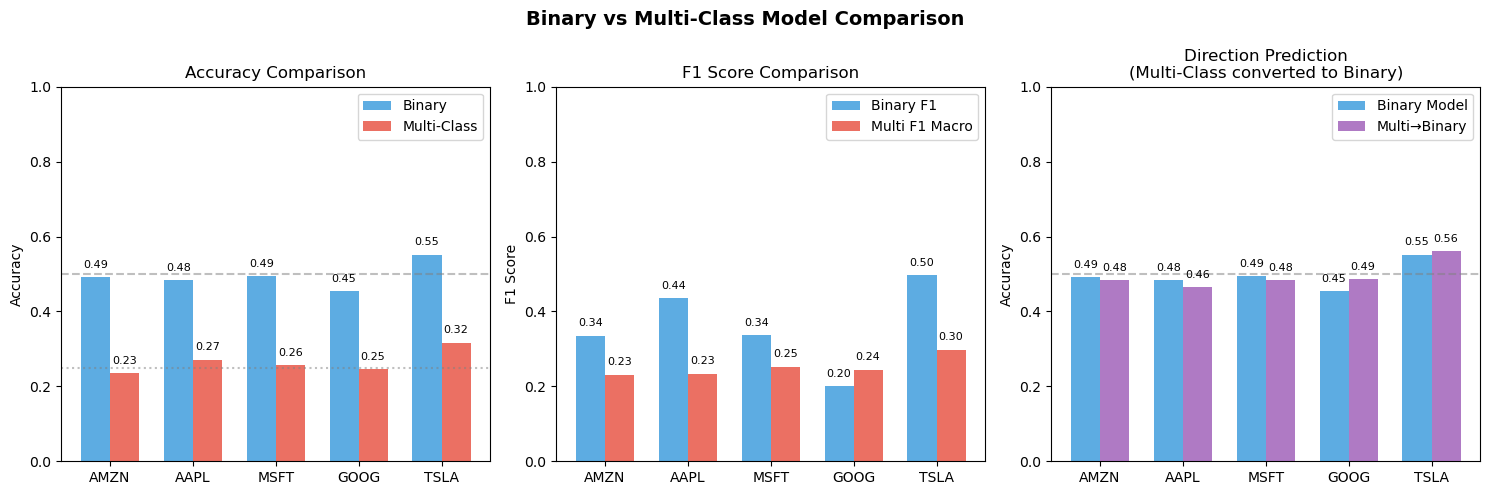

In [16]:
def plot_comparison(comparison_df):
    """Visualize Binary vs Multi-Class performance."""
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    tickers = comparison_df["Ticker"].tolist()
    x = np.arange(len(tickers))
    width = 0.35
    
    # ── Plot 1: Accuracy Comparison ──
    ax1 = axes[0]
    bars1 = ax1.bar(x - width/2, comparison_df["Binary_Acc"], width, 
                    label="Binary", color="#3498db", alpha=0.8)
    bars2 = ax1.bar(x + width/2, comparison_df["Multi_Acc"], width, 
                    label="Multi-Class", color="#e74c3c", alpha=0.8)
    
    ax1.set_ylabel("Accuracy")
    ax1.set_title("Accuracy Comparison")
    ax1.set_xticks(x)
    ax1.set_xticklabels(tickers)
    ax1.legend()
    ax1.set_ylim(0, 1)
    ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Random (Binary)")
    ax1.axhline(y=0.25, color="gray", linestyle=":", alpha=0.5, label="Random (Multi)")
    
    # Add value labels
    for bar in bars1:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars2:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    
    # ── Plot 2: F1 Score Comparison ──
    ax2 = axes[1]
    bars1 = ax2.bar(x - width/2, comparison_df["Binary_F1"], width, 
                    label="Binary F1", color="#3498db", alpha=0.8)
    bars2 = ax2.bar(x + width/2, comparison_df["Multi_F1_Macro"], width, 
                    label="Multi F1 Macro", color="#e74c3c", alpha=0.8)
    
    ax2.set_ylabel("F1 Score")
    ax2.set_title("F1 Score Comparison")
    ax2.set_xticks(x)
    ax2.set_xticklabels(tickers)
    ax2.legend()
    ax2.set_ylim(0, 1)
    
    for bar in bars1:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars2:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    
    # ── Plot 3: Direction Prediction (Fair Comparison) ──
    ax3 = axes[2]
    bars1 = ax3.bar(x - width/2, comparison_df["Binary_Acc"], width, 
                    label="Binary Model", color="#3498db", alpha=0.8)
    bars2 = ax3.bar(x + width/2, comparison_df["Multi_as_Binary_Acc"], width, 
                    label="Multi→Binary", color="#9b59b6", alpha=0.8)
    
    ax3.set_ylabel("Accuracy")
    ax3.set_title("Direction Prediction\n(Multi-Class converted to Binary)")
    ax3.set_xticks(x)
    ax3.set_xticklabels(tickers)
    ax3.legend()
    ax3.set_ylim(0, 1)
    ax3.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    
    for bar in bars1:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars2:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    
    plt.suptitle("Binary vs Multi-Class Model Comparison", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{MODELS_DIR}/binary_vs_multi_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_comparison(comparison_df)

SUMMARY STATISTICS

In [17]:
def print_summary_statistics(comparison_df):
    """Print overall summary statistics."""
    
    print("\n" + "="*70)
    print("OVERALL STATISTICS")
    print("="*70)
    
    # Average metrics
    print("\nAverage Metrics Across All Tickers:")
    print("-" * 45)
    print(f"  Binary Model:")
    print(f"    Avg Accuracy: {comparison_df['Binary_Acc'].mean():.4f}")
    print(f"    Avg F1 Score: {comparison_df['Binary_F1'].mean():.4f}")
    print(f"    Avg AUC-ROC:  {comparison_df['Binary_AUC'].mean():.4f}")
    
    print(f"\n  Multi-Class Model:")
    print(f"    Avg Accuracy:    {comparison_df['Multi_Acc'].mean():.4f}")
    print(f"    Avg F1 Macro:    {comparison_df['Multi_F1_Macro'].mean():.4f}")
    print(f"    Avg F1 Weighted: {comparison_df['Multi_F1_Weighted'].mean():.4f}")
    
    print(f"\n  Multi-Class → Binary (Direction):")
    print(f"    Avg Accuracy: {comparison_df['Multi_as_Binary_Acc'].mean():.4f}")
    print(f"    Avg F1 Score: {comparison_df['Multi_as_Binary_F1'].mean():.4f}")
    
    # Winner count
    print("\n" + "-" * 45)
    print("Direction Prediction Winners:")
    winner_counts = comparison_df["Direction_Winner"].value_counts()
    for winner, count in winner_counts.items():
        print(f"  {winner}: {count} tickers")
    
    # Best performing ticker for each model type
    print("\n" + "-" * 45)
    print("Best Performing Tickers:")
    
    best_binary = comparison_df.loc[comparison_df["Binary_AUC"].idxmax()]
    print(f"  Binary (by AUC):     {best_binary['Ticker']} ({best_binary['Binary_AUC']:.4f})")
    
    best_multi = comparison_df.loc[comparison_df["Multi_F1_Macro"].idxmax()]
    print(f"  Multi (by F1 Macro): {best_multi['Ticker']} ({best_multi['Multi_F1_Macro']:.4f})")
    
    # Recommendation
    print("\n" + "="*70)
    print("RECOMMENDATION")
    print("="*70)
    
    avg_binary_direction = comparison_df["Binary_Acc"].mean()
    avg_multi_direction = comparison_df["Multi_as_Binary_Acc"].mean()
    
    if avg_binary_direction > avg_multi_direction:
        print(f"""
  For DIRECTION prediction (up/down):
  → Use BINARY model (avg accuracy: {avg_binary_direction:.4f})
  
  The binary model is simpler and predicts direction slightly better.
        """)
    else:
        print(f"""
  For DIRECTION prediction (up/down):
  → Use MULTI-CLASS model (avg accuracy: {avg_multi_direction:.4f})
  
  The multi-class model provides more nuanced predictions AND 
  predicts direction at least as well as the binary model.
        """)
    
    print(f"""
  For MAGNITUDE prediction (how much up/down):
  → Use MULTI-CLASS model
  
  Only the multi-class model distinguishes between big and small movements.
  This is useful for:
  - Sizing positions (buy more when "Big Rise" predicted)
  - Risk management (avoid trades when "Small" movements predicted)
    """)


print_summary_statistics(comparison_df)


OVERALL STATISTICS

Average Metrics Across All Tickers:
---------------------------------------------
  Binary Model:
    Avg Accuracy: 0.4951
    Avg F1 Score: 0.3611
    Avg AUC-ROC:  0.5440

  Multi-Class Model:
    Avg Accuracy:    0.2650
    Avg F1 Macro:    0.2520
    Avg F1 Weighted: 0.2584

  Multi-Class → Binary (Direction):
    Avg Accuracy: 0.4956
    Avg F1 Score: 0.4622

---------------------------------------------
Direction Prediction Winners:
  Binary: 3 tickers
  Multi→Binary: 2 tickers

---------------------------------------------
Best Performing Tickers:
  Binary (by AUC):     TSLA (0.5841)
  Multi (by F1 Macro): TSLA (0.2982)

RECOMMENDATION

  For DIRECTION prediction (up/down):
  → Use MULTI-CLASS model (avg accuracy: 0.4956)

  The multi-class model provides more nuanced predictions AND 
  predicts direction at least as well as the binary model.
        

  For MAGNITUDE prediction (how much up/down):
  → Use MULTI-CLASS model

  Only the multi-class model dist

DETAILED PER CLASS ANALYSIS


DETAILED MULTI-CLASS ANALYSIS (Per-Class Performance)

──────────────────────────────────────────────────
  AMZN
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Big Fall       0.24      0.38      0.29        82
  Small Fall       0.22      0.22      0.22        89
  Small Rise       0.20      0.19      0.19        85
    Big Rise       0.29      0.17      0.22       110

    accuracy                           0.23       366
   macro avg       0.24      0.24      0.23       366
weighted avg       0.24      0.23      0.23       366



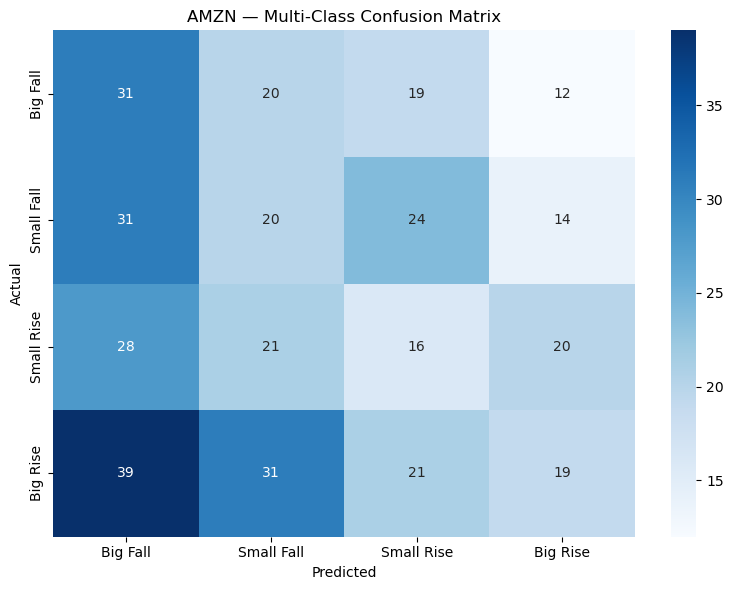


──────────────────────────────────────────────────
  AAPL
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Big Fall       0.23      0.26      0.24        62
  Small Fall       0.22      0.21      0.22       103
  Small Rise       0.31      0.47      0.38       120
    Big Rise       0.31      0.06      0.10        81

    accuracy                           0.27       366
   macro avg       0.27      0.25      0.23       366
weighted avg       0.27      0.27      0.25       366



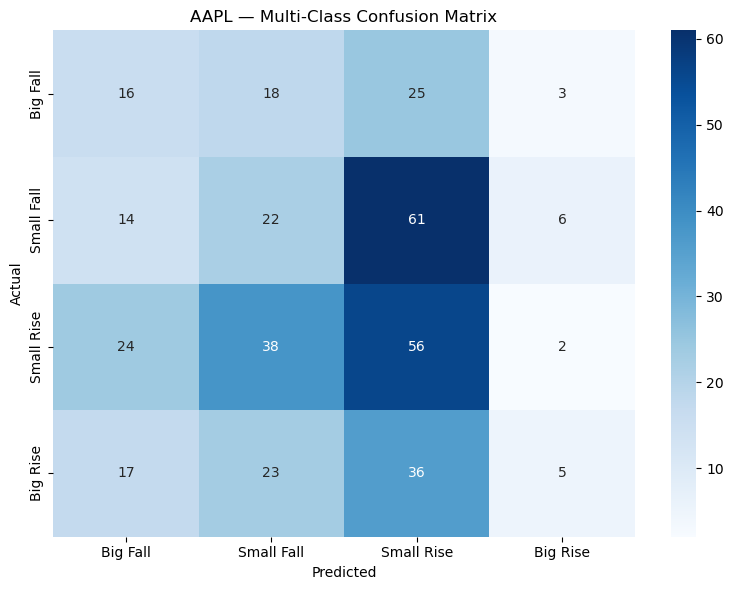


──────────────────────────────────────────────────
  MSFT
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Big Fall       0.20      0.35      0.25        63
  Small Fall       0.29      0.34      0.32       102
  Small Rise       0.36      0.15      0.22       123
    Big Rise       0.22      0.23      0.23        78

    accuracy                           0.26       366
   macro avg       0.27      0.27      0.25       366
weighted avg       0.28      0.26      0.25       366



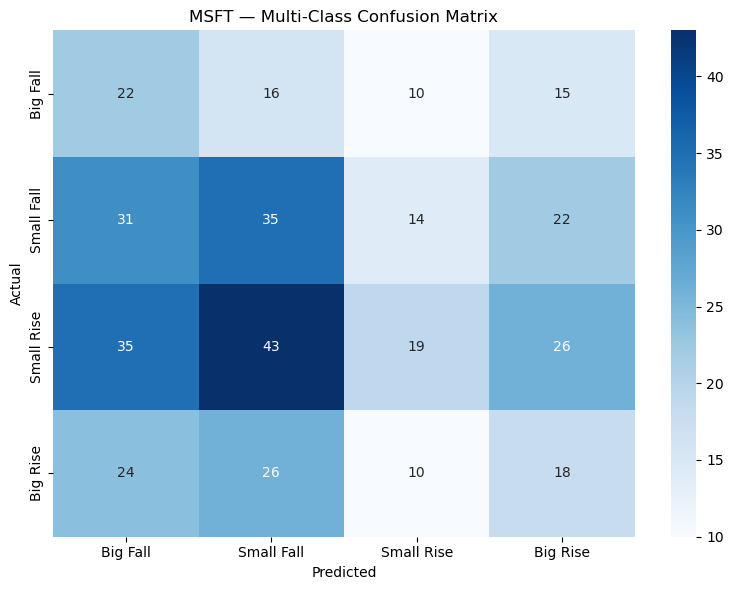


──────────────────────────────────────────────────
  GOOG
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Big Fall       0.24      0.36      0.29        85
  Small Fall       0.19      0.32      0.24        71
  Small Rise       0.25      0.13      0.18       112
    Big Rise       0.38      0.21      0.27        98

    accuracy                           0.25       366
   macro avg       0.27      0.26      0.24       366
weighted avg       0.27      0.25      0.24       366



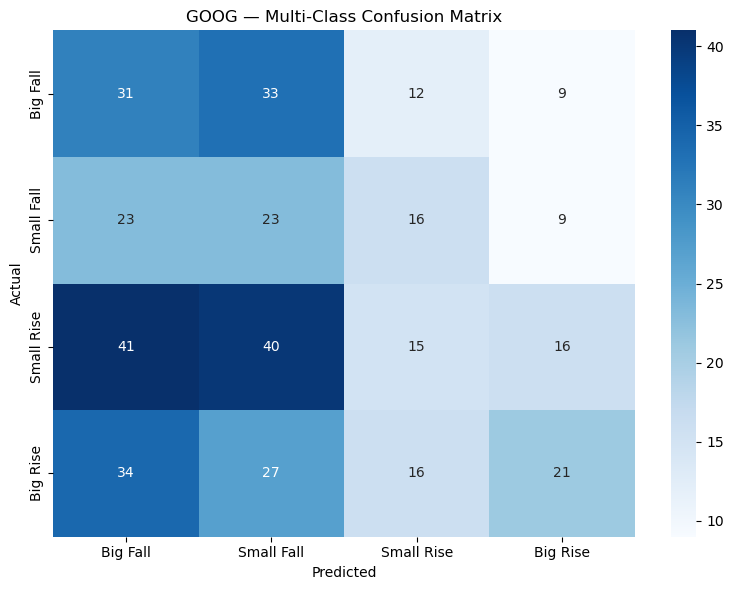


──────────────────────────────────────────────────
  TSLA
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    Big Fall       0.43      0.39      0.41       143
  Small Fall       0.20      0.40      0.27        42
  Small Rise       0.18      0.34      0.24        53
    Big Rise       0.48      0.20      0.28       128

    accuracy                           0.32       366
   macro avg       0.32      0.33      0.30       366
weighted avg       0.38      0.32      0.32       366



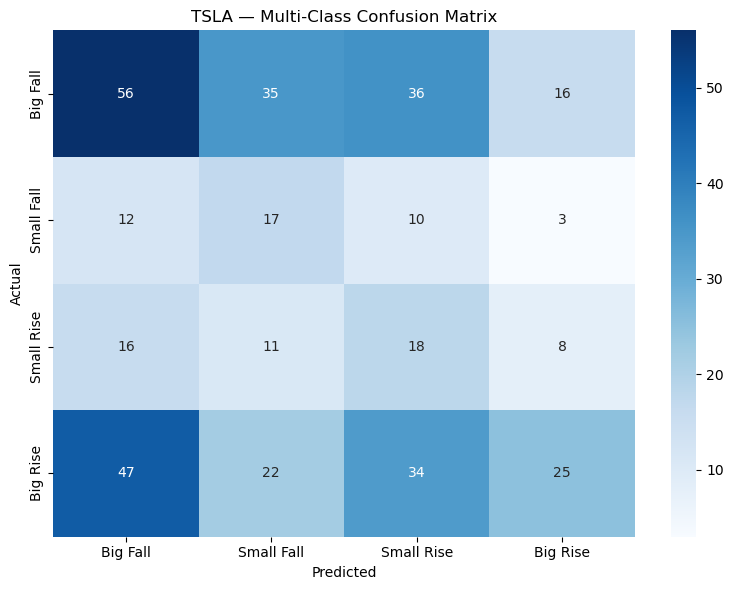

In [18]:
def detailed_multiclass_analysis():
    """Show per-class performance for multi-class model."""
    
    print("\n" + "="*70)
    print("DETAILED MULTI-CLASS ANALYSIS (Per-Class Performance)")
    print("="*70)
    
    CLASS_NAMES = ["Big Fall", "Small Fall", "Small Rise", "Big Rise"]
    
    for ticker in TICKERS:
        print(f"\n{'─'*50}")
        print(f"  {ticker}")
        print(f"{'─'*50}")
        
        try:
            # Load data and model
            path = f"{PROCESSED_DIR}/{ticker.lower()}_processed.csv"
            df = pd.read_csv(path, parse_dates=["Date"])
            df = df.sort_values("Date").reset_index(drop=True)
            df = df.dropna(subset=FEATURE_COLS + ["Target_Multi"])
            
            split_idx = int(len(df) * 0.7)
            X_test = df[FEATURE_COLS].iloc[split_idx:]
            y_test = df["Target_Multi"].iloc[split_idx:].astype(int)
            
            model = joblib.load(f"{MODELS_DIR}/model_{ticker}_multi.joblib")
            y_pred = model.predict(X_test)
            
            # Classification report
            print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
            
            # Confusion matrix
            cm = confusion_matrix(y_test, y_pred)
            
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
            plt.title(f"{ticker} — Multi-Class Confusion Matrix")
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"  ERROR: {e}")


detailed_multiclass_analysis()